In [10]:
import pandas as pd
import numpy as np

In [11]:

df = pd.read_csv("attention_detection_dataset.csv")
print(f"Dataset Shape: {df.shape}")
display(df.head())
df.info()
display(df.describe())

Dataset Shape: (6000, 17)


,no_of_face,face_x,face_y,face_w,face_h,face_con,no_of_hand,pose,pose_x,pose_y,phone,phone_x,phone_y,phone_w,phone_h,phone_con,label
0,1,256.643658,144.163663,169.071331,169.066601,88.813317,0,down,-11.569698,-1.612015,0,0,0,0,0,0.00000,1
1,1,252.967014,137.871659,163.131542,163.126974,86.704057,0,down,-15.000000,10.000000,0,0,0,0,0,0.00000,1
2,1,254.416771,134.427950,155.147362,155.145836,88.408792,0,down,-12.705953,0.082978,0,0,0,0,0,0.00000,1
3,2,256.315517,246.199763,141.227055,141.227217,89.279491,2,right,32.585681,36.572800,1,117,137,276,421,0.86614,1
4,1,293.000126,285.859563,197.011509,196.998653,80.872309,2,forward,-4.013085,-9.905692,0,0,0,0,0,0.00000,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   no_of_face  6000 non-null   int64  
 1   face_x      6000 non-null   float64
 2   face_y      6000 non-null   float64
 3   face_w      6000 non-null   float64
 4   face_h      6000 non-null   float64
 5   face_con    6000 non-null   float64
 6   no_of_hand  6000 non-null   int64  
 7   pose        6000 non-null   object 
 8   pose_x      6000 non-null   float64
 9   pose_y      6000 non-null   float64
 10  phone       6000 non-null   int64  
 11  phone_x     6000 non-null   int64  
 12  phone_y     6000 non-null   int64  
 13  phone_w     6000 non-null   int64  
 14  phone_h     6000 non-null   int64  
 15  phone_con   6000 non-null   float64
 16  label       6000 non-null   int64  
dtypes: float64(8), int64(8), object(1)
memory usage: 797.0+ KB


,no_of_face,face_x,face_y,face_w,face_h,face_con,no_of_hand,pose_x,pose_y,phone,phone_x,phone_y,phone_w,phone_h,phone_con,label
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,0.983833,245.787203,243.626163,149.728135,149.725642,85.032666,0.578000,0.046663,3.212751,0.156667,29.214833,47.361333,49.964000,70.661167,0.122957,0.438500
std,0.238568,66.216481,76.082240,45.063628,45.060238,18.696445,0.783168,8.972929,8.355003,0.363517,76.958702,116.112903,121.465879,165.215779,0.287327,0.496245
min,0.000000,-19.270037,-40.647440,0.000000,0.000000,0.000000,0.000000,-19.986642,-38.629232,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,229.883842,210.493006,132.739758,132.739828,84.459031,0.000000,-4.509500,-2.387448,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,255.440044,258.647648,147.043037,147.043090,90.710935,0.000000,1.181331,4.727598,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,277.774334,289.587386,167.499909,167.499096,94.193648,1.000000,5.450810,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,2.000000,521.506233,434.430494,486.327209,486.349926,98.507243,3.000000,40.549535,36.572800,1.000000,546.000000,447.000000,640.000000,480.000000,0.931619,1.000000


In [12]:
print("missing:\n", df.isnull().sum())
df = df.fillna(0)

print("duplicates:"+ str(df.duplicated().sum()))

df = df.drop_duplicates()

missing:
 no_of_face    0
face_x        0
face_y        0
face_w        0
face_h        0
face_con      0
no_of_hand    0
pose          0
pose_x        0
pose_y        0
phone         0
phone_x       0
phone_y       0
phone_w       0
phone_h       0
phone_con     0
label         0
dtype: int64
duplicates:119


if phone= 0, check if the phone xy wh 0
if no_of_face = 0, check that facexywh 0
if no face, diff value for pose

In [ ]:
mask_no_phone = df['phone'] == 0
df.loc[mask_no_phone, ['phone_x', 'phone_y', 'phone_w', 'phone_h', 'phone_con']] = 0

#no_of_face == 0, face dimensions should be 0
mask_no_face = df['no_of_face'] == 0
df.loc[mask_no_face, ['face_x', 'face_y', 'face_w', 'face_h', 'face_con']] = 0

In [5]:
df['face_w'] = df['face_w'].clip(lower=0)
df['face_h'] = df['face_h'].clip(lower=0)
df['phone_w'] = df['phone_w'].clip(lower=0)
df['phone_h'] = df['phone_h'].clip(lower=0)

In [ ]:
#categorical variable
pose_mapping = {'forward': 0, 'left': 1, 'right': 2, 'down': 3}
if df['pose'].dtype == object:
    df['pose'] = df['pose'].map(pose_mapping)

In [8]:
df

,no_of_face,face_x,face_y,face_w,face_h,face_con,no_of_hand,pose,pose_x,pose_y,phone,phone_x,phone_y,phone_w,phone_h,phone_con,label
0,1,256.643658,144.163663,169.071331,169.066601,88.813317,0,NaN,-11.569698,-1.612015,0,0,0,0,0,0.00000,1
1,1,252.967014,137.871659,163.131542,163.126974,86.704057,0,NaN,-15.000000,10.000000,0,0,0,0,0,0.00000,1
2,1,254.416771,134.427950,155.147362,155.145836,88.408792,0,NaN,-12.705953,0.082978,0,0,0,0,0,0.00000,1
3,2,256.315517,246.199763,141.227055,141.227217,89.279491,2,NaN,32.585681,36.572800,1,117,137,276,421,0.86614,1
4,1,293.000126,285.859563,197.011509,196.998653,80.872309,2,NaN,-4.013085,-9.905692,0,0,0,0,0,0.00000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5994,1,300.838776,290.787020,131.031647,131.031704,93.980962,1,NaN,6.400843,5.158604,0,0,0,0,0,0.00000,0
5995,1,299.426575,290.767736,131.470718,131.470985,92.505115,1,NaN,6.030621,5.732029,0,0,0,0,0,0.00000,0
5996,1,319.881058,295.682144,116.230316,116.230574,81.004226,1,NaN,6.315247,12.986163,0,0,0,0,0,0.00000,0
5997,1,301.463528,289.661837,132.857532,132.856979,53.273642,1,NaN,-15.000000,10.000000,0,0,0,0,0,0.00000,1


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5881 entries, 0 to 5998
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   no_of_face  5881 non-null   int64  
 1   face_x      5881 non-null   float64
 2   face_y      5881 non-null   float64
 3   face_w      5881 non-null   float64
 4   face_h      5881 non-null   float64
 5   face_con    5881 non-null   float64
 6   no_of_hand  5881 non-null   int64  
 7   pose        5881 non-null   object 
 8   pose_x      5881 non-null   float64
 9   pose_y      5881 non-null   float64
 10  phone       5881 non-null   int64  
 11  phone_x     5881 non-null   int64  
 12  phone_y     5881 non-null   int64  
 13  phone_w     5881 non-null   int64  
 14  phone_h     5881 non-null   int64  
 15  phone_con   5881 non-null   float64
 16  label       5881 non-null   int64  
dtypes: float64(8), int64(8), object(1)
memory usage: 827.0+ KB


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
df = df.dropna()
X = df.drop(columns=['label'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [9]:
df

,no_of_face,face_x,face_y,face_w,face_h,face_con,no_of_hand,pose_x,pose_y,phone,phone_x,phone_y,phone_w,phone_h,phone_con,label,pose_forward,pose_left,pose_right
0,1,256.643658,144.163663,169.071331,169.066601,88.813317,0,-11.569698,-1.612015,0,0,0,0,0,0.00000,1,False,False,False
1,1,252.967014,137.871659,163.131542,163.126974,86.704057,0,-15.000000,10.000000,0,0,0,0,0,0.00000,1,False,False,False
2,1,254.416771,134.427950,155.147362,155.145836,88.408792,0,-12.705953,0.082978,0,0,0,0,0,0.00000,1,False,False,False
3,2,256.315517,246.199763,141.227055,141.227217,89.279491,2,32.585681,36.572800,1,117,137,276,421,0.86614,1,False,False,True
4,1,293.000126,285.859563,197.011509,196.998653,80.872309,2,-4.013085,-9.905692,0,0,0,0,0,0.00000,1,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,299.426575,290.767736,131.470718,131.470985,92.505115,1,6.030621,5.732029,0,0,0,0,0,0.00000,0,True,False,False
5996,1,319.881058,295.682144,116.230316,116.230574,81.004226,1,6.315247,12.986163,0,0,0,0,0,0.00000,0,True,False,False
5997,1,301.463528,289.661837,132.857532,132.856979,53.273642,1,-15.000000,10.000000,0,0,0,0,0,0.00000,1,False,False,False
5998,1,322.644005,295.714903,112.505684,112.505665,72.442019,1,-15.000000,10.000000,0,0,0,0,0,0.00000,1,False,False,False


In [4]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9950

Confusion Matrix:
 [[670   4]
 [  2 524]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       674
           1       0.99      1.00      0.99       526

    accuracy                           0.99      1200
   macro avg       0.99      1.00      0.99      1200
weighted avg       1.00      0.99      1.00      1200



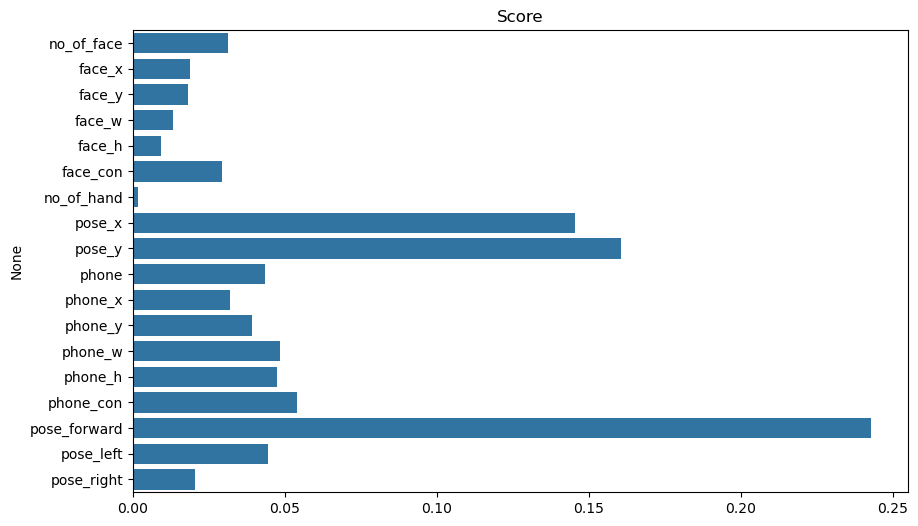

In [11]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Score')
plt.show()